In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Harsh Kaushik\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_india=df[(df['job_country']=='India')].dropna(subset=['job_skills'])
job_titles=df_india['job_title_short'].value_counts().index[:6].tolist()
df_india_top6=df_india[df_india['job_title_short'].isin(job_titles)]

In [11]:
job_order=df_india_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

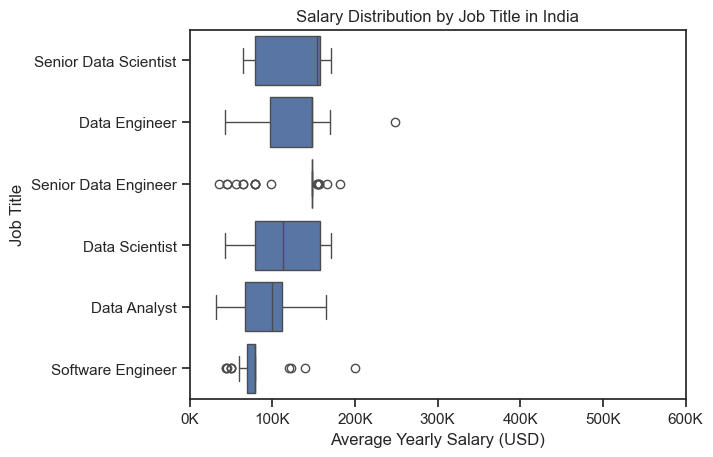

In [12]:
sns.boxplot(data=df_india_top6, x='salary_year_avg',y='job_title_short',order=job_order)
sns.set_theme(style='ticks')
plt.title('Salary Distribution by Job Title in India')
plt.xlabel('Average Yearly Salary (USD)')
plt.ylabel('Job Title')
plt.xlim(0, 600000)
from matplotlib.ticker import FuncFormatter
ticks_x=plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)    
plt.show()